In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
sns.set_theme(palette="colorblind")

In [2]:
url = "https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/simulated_items_sales.csv"

df = pd.read_csv(url, parse_dates=['date'], index_col='date')
df.index.freq = 'D'
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1097 entries, 2012-01-01 to 2015-01-01
Freq: D
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   item_1  1097 non-null   float64
 1   item_2  1097 non-null   float64
 2   item_3  1097 non-null   float64
dtypes: float64(3)
memory usage: 34.3 KB


In [22]:
df.head()

,item_1,item_2,item_3,month
date,,,,
2012-01-01,8.253175,21.047727,19.429739,1
2012-01-02,22.777826,26.578125,28.009863,1
2012-01-03,27.549099,31.751042,32.078922,1
2012-01-04,25.895533,24.567708,27.252276,1
2012-01-05,21.379238,18.191667,20.357737,1


In [4]:
# will use 80% for training, so the last training set date is:
train_size = int(df.shape[0]*0.8)
train_end = df.index[train_size]
train_end

Timestamp('2014-05-27 00:00:00')

In [5]:
# will use 80% of the training set for training, 20% for validation
train_size_cv = int(train_size*0.8)
train_end_cv = df.index[train_size_cv]
train_end_cv

Timestamp('2013-12-02 00:00:00')

In [6]:
# create a column for month to capture annual seasonality
df.loc[:, 'month'] = df.index.month

# Train-test split

In [7]:
train_set = df.iloc[:train_size].copy()
test_set = df.iloc[train_size:].copy()

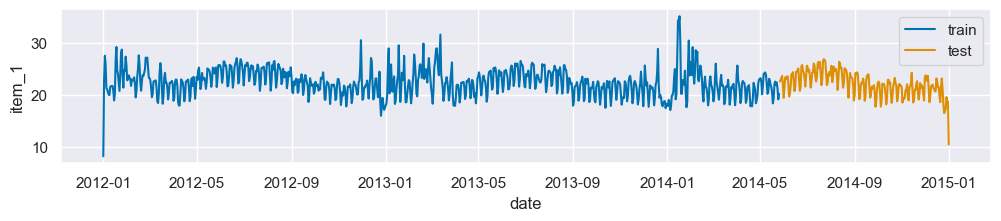

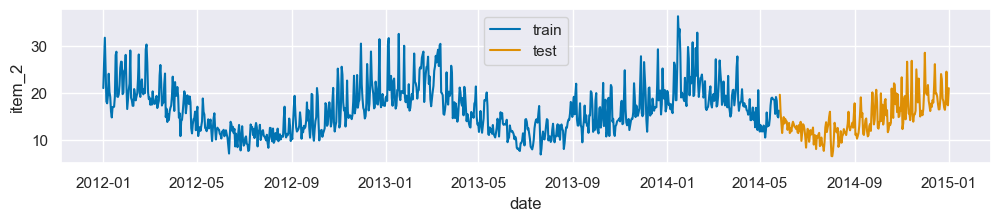

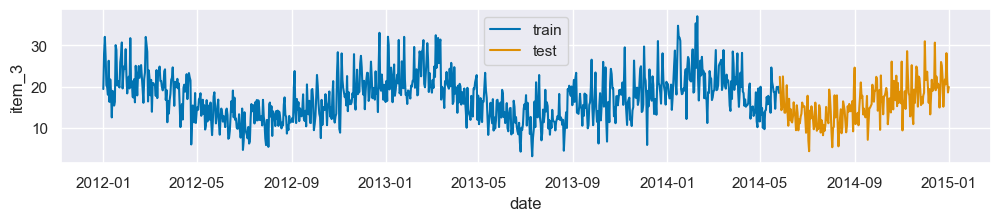

In [ ]:
import matplotlib.pyplot as plt

for x in df.columns:
    if not x.startswith("item"):
        continue
    fig, ax = plt.subplots()
    fig.set_size_inches(12, 2)
    sns.lineplot(data=train_set, x=train_set.index, y=x, label='train')
    sns.lineplot(data=test_set, x=test_set.index, y=x, label='test')

# Set up TimeSeriesFold

In [9]:
from skforecast.model_selection import TimeSeriesFold
from sklearn.metrics import root_mean_squared_error

cv = TimeSeriesFold(
         steps=24,
         initial_train_size=train_size,
         fold_stride=None,
         refit=False
     )

# Baseline

In [ ]:
# last-value baseline
from skforecast.model_selection import backtesting_forecaster
from skforecast.recursive import ForecasterEquivalentDate


results_list = []

for col in train_set.columns:

    if not col.startswith('item'):
        continue

    last_value_forecaster = ForecasterEquivalentDate(offset=1, n_offsets=1)

    results, predictions_backtest = backtesting_forecaster(
        forecaster=last_value_forecaster,
        y=df[col],
        cv=cv,
        metric=[root_mean_squared_error, 
                'mean_absolute_error'],
        n_jobs='auto',
        verbose=False,
        show_progress=True
    )
    results.index = [col]
    results_list.append(results)

baseline_results = pd.concat(results_list, axis=0)
baseline_results.loc["average"] = baseline_results.mean(axis=0)
baseline_results

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
item_1,2.379760,1.912030
item_2,3.512498,2.684428
item_3,4.928060,4.021367
average,3.606773,2.872609


# Hyperparameter optimisation

In [ ]:
from skforecast.recursive import ForecasterRecursiveMultiSeries
from sklearn.ensemble import RandomForestRegressor


forecaster = ForecasterRecursiveMultiSeries(
    estimator=RandomForestRegressor(random_state=7),
    lags=3,
    encoding='onehot', # how entity ids are encoded; None - do not use any encoding
)

In [25]:
X_train, y_train = forecaster.create_train_X_y(
                       series=train_set.drop(columns="month"),
                       exog=train_set['month']
                   )
X_train.head()

,lag_1,lag_2,lag_3,item_1,item_2,item_3,month
2012-01-04,27.549099,22.777826,8.253175,1,0,0,1
2012-01-05,25.895533,27.549099,22.777826,1,0,0,1
2012-01-06,21.379238,25.895533,27.549099,1,0,0,1
2012-01-07,21.106643,21.379238,25.895533,1,0,0,1
2012-01-08,20.533871,21.106643,21.379238,1,0,0,1


In [26]:
y_train

2012-01-04    25.895533
2012-01-05    21.379238
2012-01-06    21.106643
2012-01-07    20.533871
2012-01-08    20.069327
                ...    
2014-05-22    18.296859
2014-05-23    19.947860
2014-05-24    19.641262
2014-05-25    19.999694
2014-05-26    18.488828
Name: y, Length: 2622, dtype: float64

In [ ]:
import warnings

from skforecast.model_selection import backtesting_forecaster_multiseries
from skforecast.model_selection import grid_search_forecaster_multiseries
from skforecast.exceptions import InputTypeWarning
warnings.simplefilter('ignore', category=InputTypeWarning)


lags_grid = {
    '24 lags': 24,
    '48 lags': 48
}

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 7, 10]
}

cv_hp_search = TimeSeriesFold(
         steps=24,
         initial_train_size=train_size_cv,
         fold_stride=None,
         refit=False
     )

results_search = grid_search_forecaster_multiseries(
    forecaster=forecaster,
    series=train_set.drop(columns='month'),
    exog=train_set['month'],
    lags_grid=lags_grid,
    param_grid=param_grid,
    cv=cv_hp_search,
    levels=None,
    metric=[root_mean_squared_error, 'mean_absolute_error'],
    aggregate_metric='weighted_average',
    suppress_warnings=True,
    return_best=True
)

results_search.head(3)

lags grid:   0%|          | 0/2 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

,levels,lags,lags_label,params,root_mean_squared_error__weighted_average,mean_absolute_error__weighted_average,max_depth,n_estimators
0,"[item_1, item_2, item_3]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",24 lags,"{'max_depth': 7, 'n_estimators': 100}",3.980880,2.975314,7,100
1,"[item_1, item_2, item_3]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",24 lags,"{'max_depth': 7, 'n_estimators': 200}",4.005163,2.985991,7,200
2,"[item_1, item_2, item_3]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",48 lags,"{'max_depth': 10, 'n_estimators': 200}",4.051586,2.996333,10,200
3,"[item_1, item_2, item_3]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",24 lags,"{'max_depth': 3, 'n_estimators': 100}",4.068312,3.041683,3,100
4,"[item_1, item_2, item_3]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",48 lags,"{'max_depth': 10, 'n_estimators': 100}",4.069064,3.021014,10,100
5,"[item_1, item_2, item_3]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",24 lags,"{'max_depth': 10, 'n_estimators': 100}",4.073868,3.043709,10,100
6,"[item_1, item_2, item_3]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",24 lags,"{'max_depth': 10, 'n_estimators': 200}",4.073916,3.043898,10,200
7,"[item_1, item_2, item_3]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",24 lags,"{'max_depth': 3, 'n_estimators': 200}",4.077026,3.055888,3,200
8,"[item_1, item_2, item_3]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",48 lags,"{'max_depth': 3, 'n_estimators': 100}",4.100625,3.049610,3,100
9,"[item_1, item_2, item_3]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",48 lags,"{'max_depth': 3, 'n_estimators': 200}",4.115475,3.060566,3,200


In [14]:
best_params = results_search['params'].iat[0]
best_params

{'max_depth': 7, 'n_estimators': 100}

In [15]:
best_lags = results_search['lags'].iat[0]
best_lags

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

# Model evaluation

In [16]:
metrics, predictions = backtesting_forecaster_multiseries(
    forecaster=forecaster,
    series=df.drop(columns='month'),
    exog=df['month'],
    cv=cv,
    levels=None, # list of levels to calculate metrics; None - all levels
    metric=[root_mean_squared_error, 'mean_absolute_error'],
    add_aggregated_metric=True
)


  0%|          | 0/10 [00:00<?, ?it/s]

In [17]:
metrics

,levels,root_mean_squared_error,mean_absolute_error
0,item_1,1.883011,1.443460
1,item_2,2.920498,2.194936
2,item_3,4.280334,3.404953
3,average,3.027948,2.347783
4,weighted_average,3.027948,2.347783
5,pooling,3.183096,2.347783


In [18]:
predictions.head(6)

,level,fold,pred
2014-05-27,item_1,0,21.939534
2014-05-27,item_2,0,15.923452
2014-05-27,item_3,0,17.829372
2014-05-28,item_1,0,22.364882
2014-05-28,item_2,0,16.044364
2014-05-28,item_3,0,18.804254


# Plot predictions

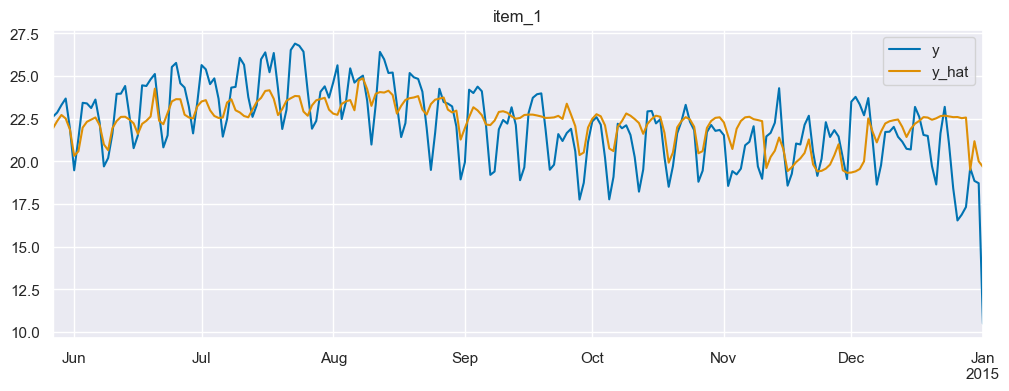

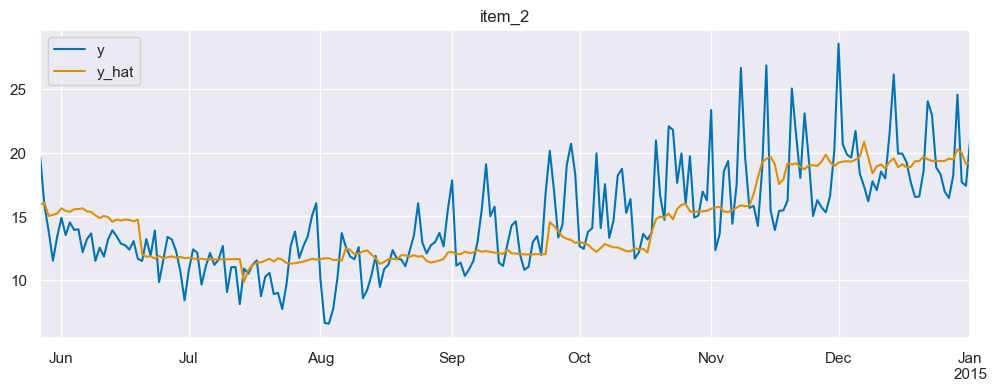

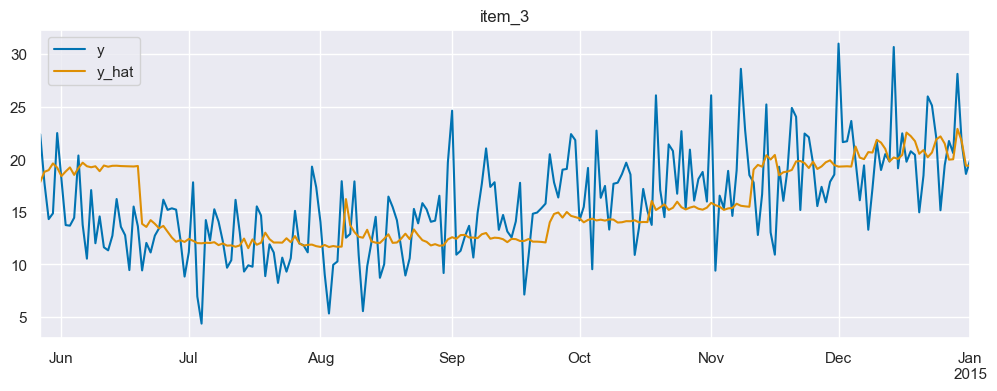

In [ ]:
# for each item
for item in df.columns:
    if not item.startswith("item"):
        continue
    y_hat = predictions[predictions["level"] == item]['pred']
    tdf = pd.DataFrame({"y": test_set[item], "y_hat": y_hat})
    tdf.plot(figsize=(12,4), title=item)

# Feature importances

In [21]:
forecaster.fit(series=df.drop(columns='month'), exog=df['month'])
importances = forecaster.get_feature_importances()
importances

,feature,importance
0,lag_1,0.735546
5,lag_6,0.027969
6,lag_7,0.026355
4,lag_5,0.020648
10,lag_11,0.016157
13,lag_14,0.013977
11,lag_12,0.013706
19,lag_20,0.013138
12,lag_13,0.010769
3,lag_4,0.010434


# Citing this notebook

If you use this notebook in your work, please cite it as follows:
    
Pekar, V. (2026). Business Forecasting. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bf